### **Lista Extra: Classificação de imagens com Redes Convolucionais (CNN) - Cachorros vs. Gatos**


Introcao

#### **Etapa 0: Importação de bibliotecas e seleção dos dados**


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import shutil
import random
from PIL import Image

BASE_PATH = "/content/drive/MyDrive/datasets/Pet_Images"
WORK_PATH = "/content/drive/MyDrive/datasets/PetImages_work"

cats_src = os.path.join(BASE_PATH, "Cats")
dogs_src = os.path.join(BASE_PATH, "Dogs")

for split in ["train", "val", "test"]:
    for cls in ["Cats", "Dogs"]:
        os.makedirs(os.path.join(WORK_PATH, split, cls), exist_ok=True)

def get_valid_images(folder, max_images=1000):
    images = []
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        try:
            img = Image.open(path)
            img.verify()
            images.append(file)
        except:
            continue
        if len(images) >= max_images:
            break
    return images

cats = get_valid_images(cats_src, 1000)
dogs = get_valid_images(dogs_src, 1000)

print(f"Gatos selecionados: {len(cats)}")
print(f"Cachorros selecionados: {len(dogs)}")



Mounted at /content/drive
Gatos selecionados: 1000
Cachorros selecionados: 1000


- A base original possui algumas imagens corrompidas, o que pode causar erros durante o treinamento.
Nesta etapa, são selecionadas automaticamente 1000 imagens válidas de gatos e 1000 de cachorros, garantindo uma base balanceada.
O uso de uma base reduzida permite acelerar o treinamento sem comprometer significativamente o desempenho do modelo.

In [ ]:
def split_and_copy(images, src_folder, class_name):
    random.shuffle(images)

    train_end = int(0.7 * len(images))
    val_end = int(0.85 * len(images))

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, files in splits.items():
        for file in files:
            src = os.path.join(src_folder, file)
            dst = os.path.join(WORK_PATH, split, class_name, file)
            shutil.copy(src, dst)

split_and_copy(cats, cats_src, "Cats")
split_and_copy(dogs, dogs_src, "Dogs")


- Distribuição das imagens em 3 subconjuntos:

    - 70% para treinamento
    - 15% para validação
    - 15% para teste


In [ ]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    print("Gatos:", len(os.listdir(os.path.join(WORK_PATH, split, "Cats"))))
    print("Cachorros:", len(os.listdir(os.path.join(WORK_PATH, split, "Dogs"))))



TRAIN
Gatos: 990
Cachorros: 917

VAL
Gatos: 478
Cachorros: 273

TEST
Gatos: 480
Cachorros: 275


#### **Etapa 1: Pré-processamento**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

- O pré-processamento das imagens inclui:

    - Redimensionamento para um tamanho padrão

    - Normalização dos pixels

    - Aumento de dados (Data Augmentation)

O aumento de dados permite gerar variações das imagens de treino, como rotações e espelhamentos, melhorando a capacidade de generalização do modelo.

In [ ]:
import shutil
import os

for split in ["train", "val", "test"]:
    checkpoint_path = os.path.join(WORK_PATH, split, ".ipynb_checkpoints")
    if os.path.exists(checkpoint_path):
        shutil.rmtree(checkpoint_path)
        print(f"Removido: {checkpoint_path}")

In [ ]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(WORK_PATH, "train"),
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary"
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(WORK_PATH, "val"),
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary"
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(WORK_PATH, "test"),
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)


Found 1907 images belonging to 2 classes.
Found 751 images belonging to 2 classes.
Found 755 images belonging to 2 classes.


#### **Etapa 2: Construção e treinamento da CNN**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [ ]:
model = Sequential()

# Camada convolucional 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Camada convolucional 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Camada convolucional 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten
model.add(Flatten())

# Camada densa
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Camada de saída
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

- Nesta etapa foi construída uma Rede Neural Convolucional (CNN) simples.
 A arquitetura é composta por três blocos de camadas Conv2D + MaxPooling, responsáveis pela extração de características das imagens.
Após a extração, os mapas de características são achatados com a camada Flatten e enviados para uma camada totalmente conectada (Dense).
A camada final utiliza a função de ativação sigmoid, adequada para problemas de classificação binária (gatos vs cachorros).

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


O modelo foi compilado utilizando:

- Otimizador Adam, amplamente utilizado em redes neurais profundas

- Função de perda binary_crossentropy, adequada para classificação binária

- Métrica de acurácia, para acompanhar o desempenho durante o treinamento

A taxa de aprendizado foi ajustada para um valor baixo, visando maior estabilidade no treinamento.

#### **Treinamento do modelo**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [ ]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - accuracy: 0.5035 - loss: 0.7003 - val_accuracy: 0.3688 - val_loss: 0.7085
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.5551 - loss: 0.6821 - val_accuracy: 0.5060 - val_loss: 0.6957
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.5988 - loss: 0.6695 - val_accuracy: 0.6325 - val_loss: 0.6434
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.6688 - loss: 0.6261 - val_accuracy: 0.6418 - val_loss: 0.6287
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.6651 - loss: 0.6257 - val_accuracy: 0.7217 - val_loss: 0.5767
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.6548 - loss: 0.6145 - val_accuracy: 0.6152 - val_loss: 0.6455
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.7021 - loss: 0.5832 - val_accuracy: 0.6831 - val_loss: 0.5861
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.7035 - loss: 0.5879 - val_accuracy: 0.6458 - v

- O modelo foi treinado por até 20 épocas, utilizando o conjunto de validação para monitorar o desempenho.
Foi aplicado o callback EarlyStopping, que interrompe o treinamento caso a perda de validação não melhore após 5 épocas consecutivas.
Essa estratégia ajuda a evitar overfitting e reduz o tempo de treinamento.

**– Visualização da acurácia e perda**

In [ ]:
import matplotlib.pyplot as plt


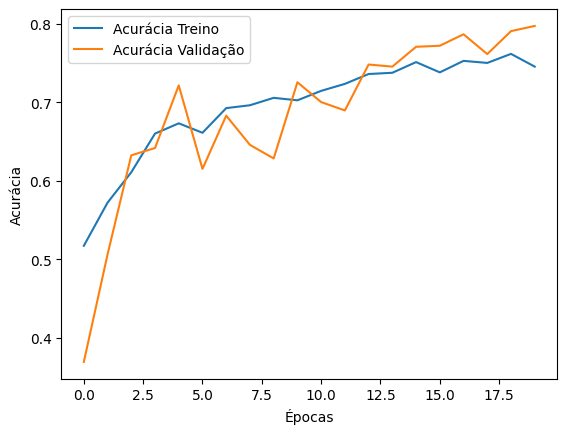

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'], label='Acurácia Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.show()


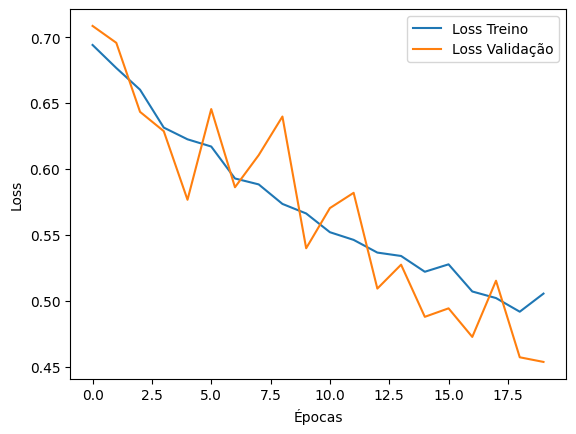

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Loss Treino')
plt.plot(history.history['val_loss'], label='Loss Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()


Os gráficos acima mostram a evolução da acurácia e da função de perda ao longo das épocas.
Essas visualizações permitem avaliar o comportamento do modelo durante o treinamento e verificar possíveis sinais de overfitting ou underfitting.

#### **Etapa 3: Avaliação do modelo no conjunto de teste**

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Acurácia no conjunto de teste: {test_acc:.4f}")


24/24 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.8458 - loss: 0.3859
Acurácia no conjunto de teste: 0.8040


Aqui, o modelo treinado foi avaliado utilizando o conjunto de teste, que contém imagens nunca vistas durante o treinamento.
Essa avaliação fornece uma estimativa mais realista do desempenho do modelo em dados novos.

**- Métricas: Precision, Recall e F1-Score**

In [ ]:
import numpy as np
from sklearn.metrics import classification_report


In [ ]:
pred_probs = model.predict(test_generator)
pred_labels = (pred_probs > 0.5).astype(int)

true_labels = test_generator.classes


24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 529ms/step


In [ ]:
print(classification_report(
    true_labels,
    pred_labels,
    target_names=['Cats', 'Dogs']
))


              precision    recall  f1-score   support

        Cats       0.84      0.86      0.85       480
        Dogs       0.74      0.71      0.73       275

    accuracy                           0.80       755
   macro avg       0.79      0.78      0.79       755
weighted avg       0.80      0.80      0.80       755



#### Testes

- Função de pré-processamento e predição

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt


In [ ]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        label = "Dog"
        confidence = prediction
    else:
        label = "Cat"
        confidence = 1 - prediction

    return img, label, confidence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


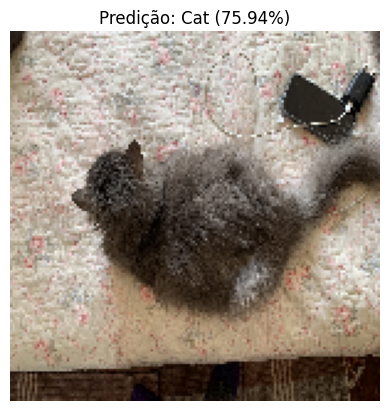

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


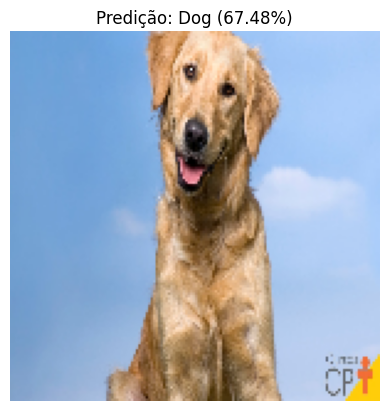

In [ ]:
test_images = [
    "/gato_teste.jpg",
    "/dog_teste.jpg"
]

for img_path in test_images:
    img, label, confidence = predict_image(img_path)

    plt.figure()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predição: {label} ({confidence*100:.2f}%)")
    plt.show()


####